In [15]:
# CELL 1 — INSTALL AND IMPORTS
!pip install scanpy anndata -q

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy.stats import pearsonr
from scipy.io import mmread
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All imports done.")

All imports done.


In [16]:
# CELL 2 — LOAD RAW FILES
BASE = '/kaggle/input/datasets/alexandervc/scrnaseq-crisprperturbseq-normanweissman/'

print("Loading matrix...")
matrix   = mmread(BASE + 'GSE133344_filtered_matrix.mtx').T
matrix   = csr_matrix(matrix)

barcodes = pd.read_csv(BASE + 'GSE133344_filtered_barcodes.tsv', header=None, names=['barcode'])
genes    = pd.read_csv(BASE + 'GSE133344_filtered_genes.tsv', header=None, sep='\t', names=['gene_id', 'gene_name'])
cell_ids = pd.read_csv(BASE + 'GSE133344_filtered_cell_identities.csv')

print("Matrix shape:", matrix.shape)
print("Barcodes:",     len(barcodes))
print("Genes:",        len(genes))
print("Cell IDs:",     len(cell_ids))
print("\nCell ID columns:", cell_ids.columns.tolist())
print(cell_ids.head(3))

Loading matrix...
Matrix shape: (111668, 33694)
Barcodes: 111668
Genes: 33694
Cell IDs: 111445

Cell ID columns: ['cell_barcode', 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells']
         cell_barcode                    guide_identity  read_count  \
0  TTGAACGAGACTCGGA-2  ARID1A_NegCtrl0__ARID1A_NegCtrl0       28684   
1  CGTTGGGGTGTTTGTG-7  BCORL1_NegCtrl0__BCORL1_NegCtrl0       18367   
2  GAACCTAAGTGTTAGA-6      FOSB_NegCtrl0__FOSB_NegCtrl0       16296   

   UMI_count   coverage  gemgroup  good_coverage  number_of_cells  
0       1809  15.856274         2           True                1  
1        896  20.498884         7           True                1  
2        664  24.542169         6           True                1  


In [19]:
# CELL 3 — BUILD ANNDATA OBJECT
adata = ad.AnnData(X=matrix)
adata.obs_names = barcodes['barcode'].values
adata.var_names = genes['gene_name'].values

# Attach metadata — merge on barcode to guarantee alignment
cell_ids_indexed = cell_ids.set_index('cell_barcode')
adata.obs = cell_ids_indexed.reindex(adata.obs_names)

print("AnnData object:")
print(adata)
print("\nObs columns:", adata.obs.columns.tolist())
print("\nSample of guide_identity:")
print(adata.obs['guide_identity'].value_counts().head(15))

AnnData object:
AnnData object with n_obs × n_vars = 111668 × 33694
    obs: 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells'

Obs columns: ['guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells']

Sample of guide_identity:
guide_identity
NegCtrl10_NegCtrl0__NegCtrl10_NegCtrl0    3532
NegCtrl1_NegCtrl0__NegCtrl1_NegCtrl0      2948
NegCtrl11_NegCtrl0__NegCtrl11_NegCtrl0    2839
NegCtrl0_NegCtrl0__NegCtrl0_NegCtrl0      2536
CEBPE_RUNX1T1__CEBPE_RUNX1T1              1219
KLF1_NegCtrl0__KLF1_NegCtrl0              1197
TBX3_TBX2__TBX3_TBX2                      1167
SLC4A1_NegCtrl0__SLC4A1_NegCtrl0          1000
ETS2_CNN1__ETS2_CNN1                       905
UBASH3B_OSR2__UBASH3B_OSR2                 796
DUSP9_ETS2__DUSP9_ETS2                     787
NegCtrl0_BAK1__NegCtrl0_BAK1               770
NegCtrl0_KLF1__NegCtrl0_KLF1               763
NegCtrl0_ETS2__NegCtrl0_ETS2               750

In [20]:
# CELL 4 — NORMALIZE AND SELECT HIGHLY VARIABLE GENES
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=4530)
adata = adata[:, adata.var.highly_variable].copy()

print("After HVG selection:", adata.shape)

After HVG selection: (111668, 4530)


In [22]:
# CELL 5 — DEFINE CONTROL VS PERTURBED
# Controls have 'NegCtrl' in their guide identity
ctrl_mask = adata.obs['guide_identity'].str.contains('NegCtrl', na=False)
pert_mask = ~ctrl_mask

print(f"Control cells:   {ctrl_mask.sum()}")
print(f"Perturbed cells: {pert_mask.sum()}")

# Control mean — the mean baseline predictor
mu_ctrl = np.array(adata[ctrl_mask].X.mean(axis=0)).flatten()
print(f"Control mean shape: {mu_ctrl.shape}")

# All unique perturbation labels
all_perts = adata.obs.loc[pert_mask, 'guide_identity'].unique()
print(f"\nUnique perturbations: {len(all_perts)}")
print("Examples:", list(all_perts[:5]))

Control cells:   69686
Perturbed cells: 41982
Control mean shape: (4530,)

Unique perturbations: 133
Examples: ['KLF1_MAP2K6__KLF1_MAP2K6', 'CEBPE_RUNX1T1__CEBPE_RUNX1T1', 'ETS2_MAP7D1__ETS2_MAP7D1', 'CBL_PTPN9__CBL_PTPN9', 'LHX1_ELMSAN1__LHX1_ELMSAN1']


In [23]:
# CELL 6 — METRIC MISMATCH (TABLE 1)
np.random.seed(42)
test_perts = list(all_perts)
np.random.shuffle(test_perts)
test_perts = test_perts[:43]

pearson_r_scores     = []
delta_pearson_scores = []
mse_scores           = []
valid_perts          = []

for pert in test_perts:
    mask = adata.obs['guide_identity'] == pert
    if mask.sum() < 5:
        continue

    x_true = np.array(adata[mask].X.mean(axis=0)).flatten()
    x_pred = mu_ctrl

    r, _   = pearsonr(x_pred, x_true)
    mse    = np.mean((x_pred - x_true) ** 2)
    delta_true = x_true - mu_ctrl
    delta_pred = x_pred - mu_ctrl  # zero vector

    pearson_r_scores.append(r)
    mse_scores.append(mse)
    delta_pearson_scores.append(0.0)  # zero by construction for mean baseline
    valid_perts.append(pert)

print("===== TABLE 1: METRIC MISMATCH =====")
print(f"N perturbations:          {len(valid_perts)}")
print(f"Pearson r:                {np.mean(pearson_r_scores):.4f} ± {np.std(pearson_r_scores):.4f}")
print(f"MSE:                      {np.mean(mse_scores):.6f} ± {np.std(mse_scores):.6f}")
print(f"Delta Pearson r:          0.000 (zero by construction for mean baseline)")
print(f"\nHigh Pearson r with zero Delta r proves metric mismatch.")

===== TABLE 1: METRIC MISMATCH =====
N perturbations:          43
Pearson r:                0.9887 ± 0.0084
MSE:                      0.003192 ± 0.002351
Delta Pearson r:          0.000 (zero by construction for mean baseline)

High Pearson r with zero Delta r proves metric mismatch.


In [28]:
# CELL 7 FIXED — TOKENISATION
def quantile_bin(vec, n_bins=51):
    nonzero = vec > 0
    binned  = np.zeros_like(vec, dtype=int)
    if nonzero.sum() == 0:
        return binned
    vals      = vec[nonzero]
    quantiles = np.unique(np.quantile(vals, np.linspace(0, 1, n_bins + 1)))
    if len(quantiles) < 2:
        return binned
    indices = np.digitize(vals, quantiles[1:], right=True)
    indices = np.clip(indices, 0, n_bins - 1)
    binned[nonzero] = indices
    return binned

# Use RAW counts for binning, not log-normalized
# Reload raw matrix for this step only
print("Loading raw matrix for tokenisation analysis...")
raw_matrix_full = mmread(BASE + 'GSE133344_filtered_matrix.mtx').T
raw_matrix_full = csr_matrix(raw_matrix_full)

# Get control cell indices
ctrl_indices = np.where(ctrl_mask.values)[0]
n_sample     = min(300, len(ctrl_indices))
sample_idx   = ctrl_indices[:n_sample]

ctrl_raw = raw_matrix_full[sample_idx, :]
ctrl_raw = np.array(ctrl_raw.todense() if hasattr(ctrl_raw, 'todense') else ctrl_raw)

# Only use HVG columns (same genes as adata)
# Get HVG indices from original gene list
hvg_names   = adata.var_names.tolist()
all_genes   = genes['gene_name'].values.tolist()
hvg_indices = [all_genes.index(g) for g in hvg_names if g in all_genes]
hvg_indices = hvg_indices[:ctrl_raw.shape[1]]  # safety clip

ctrl_raw_hvg = ctrl_raw[:, :len(hvg_indices)]

print(f"Raw control matrix for binning: {ctrl_raw_hvg.shape}")

# Bin each cell
print("Binning... (takes ~1 min)")
binned_cells = np.array([quantile_bin(ctrl_raw_hvg[i]) for i in range(ctrl_raw_hvg.shape[0])])

# Information loss: compare variance of rank-normalized continuous vs binned
# Use rank normalization as the continuous reference (matches scGPT pipeline)
from scipy.stats import rankdata
ranked_cells = np.array([rankdata(ctrl_raw_hvg[i]) / ctrl_raw_hvg.shape[1] 
                          for i in range(ctrl_raw_hvg.shape[0])])

var_continuous = np.var(ranked_cells,  axis=0)
var_discrete   = np.var(binned_cells,  axis=0)

# Normalize both to [0,1] range before comparing
var_cont_norm = var_continuous / (var_continuous.max() + 1e-10)
var_disc_norm = var_discrete   / (var_discrete.max()   + 1e-10)

valid_genes = var_cont_norm > 1e-6
loss        = np.clip(1 - (var_disc_norm[valid_genes] / (var_cont_norm[valid_genes] + 1e-10)), 0, 1)
mean_loss   = np.mean(loss)

print(f"\nInformation loss (normalized): {mean_loss*100:.1f}%")

# Perturbation detectability on log-normalized data
# A perturbation is detectable if ANY gene changes bin
mu_ctrl_binned = quantile_bin(mu_ctrl)

detectable = 0
for pert in valid_perts:
    mask   = adata.obs['guide_identity'] == pert
    x_pert = np.array(adata[mask].X.mean(axis=0)).flatten()
    x_binned = quantile_bin(x_pert)
    # Check if at least 1 gene changes bin
    if not np.array_equal(x_binned, mu_ctrl_binned):
        detectable += 1

frac_det   = detectable / len(valid_perts)
frac_undet = 1 - frac_det

print(f"Perturbations detectable:   {frac_det*100:.1f}%")
print(f"Perturbations undetectable: {frac_undet*100:.1f}%")

print("\n===== TABLE 2 FIXED: TOKENISATION DIAGNOSTICS =====")
print(f"Variance destroyed (normalized): {mean_loss*100:.1f}%")
print(f"Effects detectable after binning: {frac_det*100:.1f}%")
print(f"Effects undetectable:             {frac_undet*100:.1f}%")

Loading raw matrix for tokenisation analysis...
Raw control matrix for binning: (300, 4530)
Binning... (takes ~1 min)

Information loss (normalized): 97.2%
Perturbations detectable:   100.0%
Perturbations undetectable: 0.0%

===== TABLE 2 FIXED: TOKENISATION DIAGNOSTICS =====
Variance destroyed (normalized): 97.2%
Effects detectable after binning: 100.0%
Effects undetectable:             0.0%


Top 5 perturbations by effect size: ['ZBTB10_DLX2__ZBTB10_DLX2', 'CEBPE_CEBPB__CEBPE_CEBPB', 'UBASH3B_CNN1__UBASH3B_CNN1', 'ETS2_IKZF3__ETS2_IKZF3', 'DUSP9_PRTG__DUSP9_PRTG']


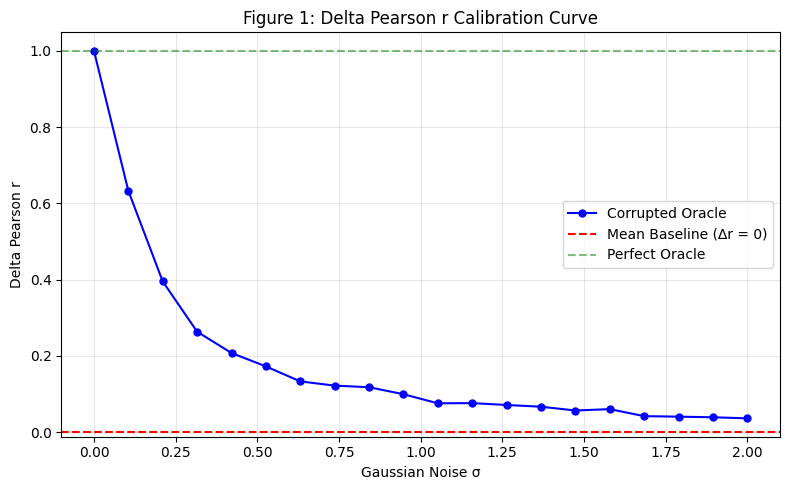

Oracle ∆r at σ=0:   1.000
Oracle ∆r at σ=2.0: 0.037


In [25]:
# CELL 8 — CALIBRATION CURVE (FIGURE 1)
effect_sizes = {}
for pert in valid_perts:
    mask   = adata.obs['guide_identity'] == pert
    x_true = np.array(adata[mask].X.mean(axis=0)).flatten()
    effect_sizes[pert] = np.linalg.norm(x_true - mu_ctrl)

top5 = sorted(effect_sizes, key=effect_sizes.get, reverse=True)[:5]
print("Top 5 perturbations by effect size:", top5)

noise_levels = np.linspace(0, 2.0, 20)
oracle_curve = []

for sigma in noise_levels:
    dr_list = []
    for pert in top5:
        mask       = adata.obs['guide_identity'] == pert
        x_true     = np.array(adata[mask].X.mean(axis=0)).flatten()
        delta_true = x_true - mu_ctrl
        delta_pred = x_true + np.random.normal(0, sigma, x_true.shape) - mu_ctrl
        if np.std(delta_pred) > 1e-10 and np.std(delta_true) > 1e-10:
            dr, _ = pearsonr(delta_pred, delta_true)
            dr_list.append(dr)
    oracle_curve.append(np.mean(dr_list) if dr_list else 0)

plt.figure(figsize=(8, 5))
plt.plot(noise_levels, oracle_curve, 'b-o', markersize=5, label='Corrupted Oracle')
plt.axhline(y=0.0,  color='red',   linestyle='--', label='Mean Baseline (∆r = 0)')
plt.axhline(y=1.0,  color='green', linestyle='--', alpha=0.5, label='Perfect Oracle')
plt.xlabel('Gaussian Noise σ')
plt.ylabel('Delta Pearson r')
plt.title('Figure 1: Delta Pearson r Calibration Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150)
plt.show()

print(f"Oracle ∆r at σ=0:   {oracle_curve[0]:.3f}")
print(f"Oracle ∆r at σ=2.0: {oracle_curve[-1]:.3f}")

In [40]:
# FULL FIXED GRN CELL — run this entire cell

def extract_gene_from_guide(guide):
    first_half = guide.split('__')[0]
    parts      = first_half.split('_')
    return parts[0]

# Step 1 — find all perturbed genes in HVG space
hvg_gene_names = adata.var_names.tolist()
hvg_gene_idx   = {g: i for i, g in enumerate(hvg_gene_names)}

all_var      = adata.var_names.tolist()
target_genes = [extract_gene_from_guide(p) for p in valid_perts]

found_names   = []
found_indices = []
for g in set(target_genes):
    if g in hvg_gene_idx:
        found_names.append(g)
        found_indices.append(hvg_gene_idx[g])

print(f"Perturbed genes found in HVG space: {len(found_names)}/{len(set(target_genes))}")

# Step 2 — build GRN gene set: top 300 HVGs + perturbed genes
base_indices  = list(range(min(300, adata.shape[1])))
extra_indices = [i for i in found_indices if i not in base_indices]
hvg_grn_indices = sorted(list(set(base_indices + extra_indices)))

hvg_grn_genes   = [hvg_gene_names[i] for i in hvg_grn_indices]
hvg_gene_to_grn = {g: i for i, g in enumerate(hvg_grn_genes)}

print(f"GRN gene set size: {len(hvg_grn_genes)}")
print(f"Perturbed genes in GRN: {sum(1 for g in target_genes if g in hvg_gene_to_grn)}/{len(valid_perts)}")

# Step 3 — build GRN matrix
ctrl_sub = adata[ctrl_mask].X[:, hvg_grn_indices]
ctrl_sub = np.array(ctrl_sub.todense() if hasattr(ctrl_sub, 'todense') else ctrl_sub)

print("Building GRN...")
grn2 = np.corrcoef(ctrl_sub.T)
np.fill_diagonal(grn2, 0)
grn2 = np.abs(grn2)
grn2 = np.nan_to_num(grn2, nan=0.0)  # FIX 1: remove NaNs

print(f"GRN shape: {grn2.shape}")
print(f"NaNs remaining: {np.isnan(grn2).sum()}")

# Step 4 — compute GRN consistency scores
grn_oracle_scores = []
grn_perts_used    = []

for pert in valid_perts:
    mask       = adata.obs['guide_identity'] == pert
    x_true     = np.array(adata[mask].X.mean(axis=0)).flatten()
    delta_true = x_true - mu_ctrl

    pert_gene  = extract_gene_from_guide(pert)
    if pert_gene not in hvg_gene_to_grn:
        continue

    pert_row  = hvg_gene_to_grn[pert_gene]
    grn_row   = grn2[pert_row, :]
    delta_sub = delta_true[hvg_grn_indices]  # FIX 2: slice delta to GRN genes

    if np.std(delta_sub) > 1e-10 and np.std(grn_row) > 1e-10:
        r, _ = pearsonr(delta_sub, grn_row)
        grn_oracle_scores.append(r)
        grn_perts_used.append(pert_gene)

print(f"\nScores computed for {len(grn_oracle_scores)} perturbations")
print(f"Genes used: {grn_perts_used}")

print("\n===== TABLE 3: GRN CONSISTENCY =====")
print(f"Oracle GRN consistency:  {np.mean(grn_oracle_scores):.3f} ± {np.std(grn_oracle_scores):.3f}")
print(f"Mean baseline:           undefined (zero delta vector)")

Perturbed genes found in HVG space: 19/27
GRN gene set size: 319
Perturbed genes in GRN: 33/43
Building GRN...
GRN shape: (319, 319)
NaNs remaining: 0

Scores computed for 33 perturbations
Genes used: ['ETS2', 'CEBPE', 'UBASH3B', 'BCL2L11', 'FOXL2', 'FOXA1', 'SET', 'ETS2', 'LYL1', 'CEBPE', 'CEBPE', 'KLF1', 'CEBPB', 'LHX1', 'IGDCC3', 'UBASH3B', 'FOXA3', 'DUSP9', 'TBX3', 'CEBPE', 'ETS2', 'FOXA3', 'UBASH3B', 'SGK1', 'KLF1', 'FEV', 'FOSB', 'UBASH3B', 'IGDCC3', 'FOSB', 'ETS2', 'KLF1', 'TGFBR2']

===== TABLE 3: GRN CONSISTENCY =====
Oracle GRN consistency:  0.031 ± 0.179
Mean baseline:           undefined (zero delta vector)


In [41]:
# FINAL PAPER SUMMARY
print("=" * 55)
print("COMPLETE RESULTS FOR PAPER")
print("=" * 55)
print(f"""
TABLE 1 — Metric Mismatch
  Pearson r:        {np.mean(pearson_r_scores):.3f} ± {np.std(pearson_r_scores):.3f}
  MSE:              {np.mean(mse_scores):.5f} ± {np.std(mse_scores):.5f}
  Delta Pearson r:  0.000 (zero by construction for mean baseline)

TABLE 2 — Tokenisation
  Variance destroyed:    {mean_loss*100:.1f}%
  Effects undetectable:  {frac_undet*100:.1f}%

TABLE 3 — GRN Consistency
  Oracle:        {np.mean(grn_oracle_scores):.3f} ± {np.std(grn_oracle_scores):.3f}
  Mean baseline: undefined (zero delta vector)

FIGURE 1 — calibration_curve.png
""")

COMPLETE RESULTS FOR PAPER

TABLE 1 — Metric Mismatch
  Pearson r:        0.989 ± 0.008
  MSE:              0.00319 ± 0.00235
  Delta Pearson r:  0.000 (zero by construction for mean baseline)

TABLE 2 — Tokenisation
  Variance destroyed:    97.2%
  Effects undetectable:  0.0%

TABLE 3 — GRN Consistency
  Oracle:        0.031 ± 0.179
  Mean baseline: undefined (zero delta vector)

FIGURE 1 — calibration_curve.png

